In [1]:
from datasets import load_dataset
from preprocessing import ArabicPreprocessor
from embedding import ArabicEmbedding
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

c:\Users\computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("arbml/Arabic_Sentiment_Twitter_Corpus")

Repo card metadata block was not found. Setting CardData to empty.


# Part 1:

### Pre Processing:


In [3]:
pre_processor = ArabicPreprocessor()
data = ds.map(lambda x: {"clean_tweet": pre_processor.preprocess(x["tweet"])})

data

DatasetDict({
    train: Dataset({
        features: ['tweet', 'label', 'clean_tweet'],
        num_rows: 47000
    })
    test: Dataset({
        features: ['tweet', 'label', 'clean_tweet'],
        num_rows: 11751
    })
})

In [4]:
train_data = data["train"].remove_columns(["tweet"])
test_data  = data["test"].remove_columns(["tweet"])

### W2V:

In [5]:
a2v = ArabicEmbedding(100,5,1,1)

In [6]:
a2v.train(train_data["clean_tweet"])

In [7]:
a2v.most_similar("رمضان")

('يبلغك', 0.7916790246963501)

In [8]:
a2v.similarity("الهلال", "النصر")

0.5363136529922485

In [9]:
# a2v.save("w2v.model")

# Part 2:

In [10]:
X_train = a2v.s2v(train_data["clean_tweet"])
X_test  = a2v.s2v(test_data["clean_tweet"])
y_train = train_data["label"]
y_test = test_data["label"]

# Part 3:

In [11]:
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(np.array(y_train), dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(np.array(y_test), dtype=torch.long).to(device)

Epoch 0: Loss = 0.6953
Epoch 1000: Loss = 0.4411
Epoch 2000: Loss = 0.4143
Epoch 3000: Loss = 0.3983
Epoch 4000: Loss = 0.3911
Epoch 5000: Loss = 0.3792
Epoch 6000: Loss = 0.3717
Epoch 7000: Loss = 0.3660
Epoch 8000: Loss = 0.3616
Epoch 9000: Loss = 0.3561
0.35208532214164734


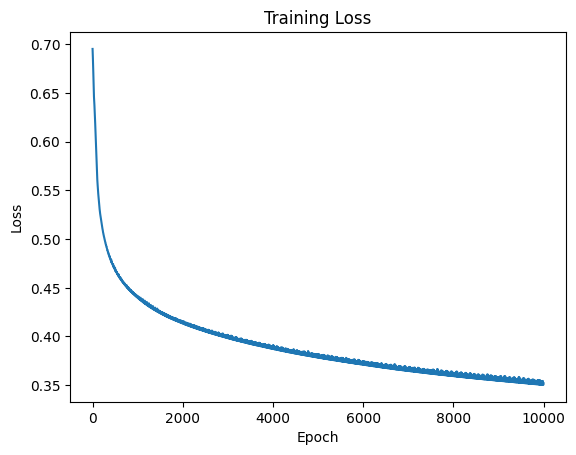

In [16]:
class SimpleClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            #nn.ReLU(),
            #nn.Linear(64, 2), 
        )

    def forward(self, x):
        return self.net(x)
    
model = SimpleClassification().to(device)
model

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []

epochs = 10000

for epoch in range(epochs):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

print(loss.item())
# ====== Plot ======
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [17]:
for epoch in range(epochs):
    pred = model(X_test)
    loss = loss_fn(pred, y_test)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

print(loss.item())

Epoch 0: Loss = 0.6342
Epoch 1000: Loss = 0.6342
Epoch 2000: Loss = 0.6342
Epoch 3000: Loss = 0.6342
Epoch 4000: Loss = 0.6342
Epoch 5000: Loss = 0.6342
Epoch 6000: Loss = 0.6342
Epoch 7000: Loss = 0.6342
Epoch 8000: Loss = 0.6342
Epoch 9000: Loss = 0.6342
0.634166955947876
